In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from scipy.stats import pearsonr
import os

# 1. 加载数据+清洗
df = pd.read_csv('sba_loan_filtered_2023-2025.csv')
print(df.isnull().sum())

df['ProfitMargin'] = df['ProfitMargin'].fillna(df['ProfitMargin'].median())
df['Industry'] = df['Industry'].fillna(df['Industry'].mode()[0])
df = df.drop_duplicates()
print(df.info())

Year                  0
Industry              0
Revenue               0
NetProfit             0
ProfitMargin          0
CurrentAssets         0
CurrentLiabilities    0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
Int64Index: 9 entries, 0 to 8
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Year                9 non-null      int64  
 1   Industry            9 non-null      object 
 2   Revenue             9 non-null      int64  
 3   NetProfit           9 non-null      int64  
 4   ProfitMargin        9 non-null      float64
 5   CurrentAssets       9 non-null      int64  
 6   CurrentLiabilities  9 non-null      int64  
dtypes: float64(1), int64(5), object(1)
memory usage: 576.0+ bytes
None


Plot saved successfully:


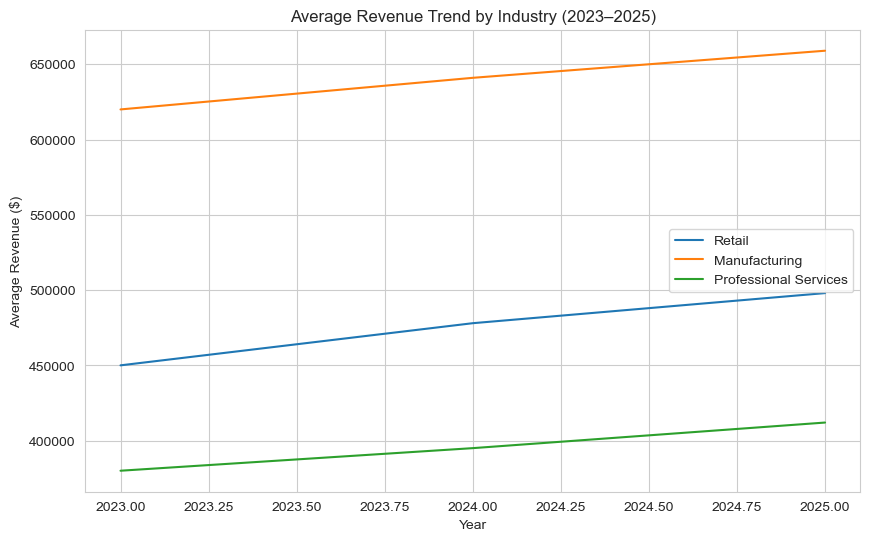

In [2]:
# 2. 绘制收入趋势图
sns.set_style('whitegrid')
plt.figure(figsize=(10, 6))
for industry in df['Industry'].unique():
    industry_data = df[df['Industry'] == industry].groupby('Year')['Revenue'].mean()
    sns.lineplot(x=industry_data.index, y=industry_data.values, label=industry)

plt.title('Average Revenue Trend by Industry (2023–2025)')
plt.xlabel('Year')
plt.ylabel('Average Revenue ($)')
plt.legend()
plt.savefig('revenue_trend.png', dpi=300, bbox_inches='tight')
print("Plot saved successfully:" if os.path.exists('revenue_trend.png') else "Plot saving failed")

In [3]:
# 3. 数据归一化
scaler = MinMaxScaler()
df[['Revenue', 'NetProfit', 'CurrentAssets', 'CurrentLiabilities']] = scaler.fit_transform(
    df[['Revenue', 'NetProfit', 'CurrentAssets', 'CurrentLiabilities']]
)
print(df[['Revenue', 'NetProfit', 'CurrentAssets', 'CurrentLiabilities']].describe())

        Revenue  NetProfit  CurrentAssets  CurrentLiabilities
count  9.000000   9.000000       9.000000            9.000000
mean   0.443250   0.467879       0.460870            0.387800
std    0.391810   0.406902       0.357290            0.403287
min    0.000000   0.000000       0.000000            0.000000
25%    0.114695   0.106087       0.217391            0.084967
50%    0.351254   0.402122       0.391304            0.215686
75%    0.860215   0.949735       0.782609            0.816993
max    1.000000   1.000000       1.000000            1.000000


In [4]:
# 4. 分行业年度汇总
industry_year_metrics = df.groupby(['Industry', 'Year']).agg({
    'Revenue': 'mean',
    'ProfitMargin': 'mean'
}).reset_index()
print(industry_year_metrics)

                Industry  Year   Revenue  ProfitMargin
0          Manufacturing  2023  0.860215          11.0
1          Manufacturing  2024  0.935484          10.7
2          Manufacturing  2025  1.000000          10.5
3  Professional Services  2023  0.000000          13.0
4  Professional Services  2024  0.053763          12.8
5  Professional Services  2025  0.114695          12.5
6                 Retail  2023  0.250896          12.2
7                 Retail  2024  0.351254          12.0
8                 Retail  2025  0.422939          11.7


In [5]:
# 5. 计算流动比率（防止除零错误）
df['CurrentRatio'] = df.apply(
    lambda row: row['CurrentAssets'] / row['CurrentLiabilities'] if row['CurrentLiabilities'] != 0 else 0,
    axis=1
)
print("Current Ratio range:", df['CurrentRatio'].min(), "to", df['CurrentRatio'].max())
print("Missing values in CurrentRatio:", df['CurrentRatio'].isnull().sum())

Current Ratio range: 0.0 to 3.193043478260872
Missing values in CurrentRatio: 0


In [6]:
# 6. 相关性分析
corr, p_value = pearsonr(df['CurrentRatio'], df['ProfitMargin'])
print(f"Pearson Correlation Coefficient: {corr:.2f}, p-value: {p_value:.4f}")

if abs(corr) < 0.3:
    print("Weak correlation between CurrentRatio and ProfitMargin")
elif 0.3 <= abs(corr) < 0.7:
    print("Moderate correlation between CurrentRatio and ProfitMargin")
else:
    print("Strong correlation between CurrentRatio and ProfitMargin")

Pearson Correlation Coefficient: 0.34, p-value: 0.3769
Moderate correlation between CurrentRatio and ProfitMargin
